In [1]:
import torch 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

# setup CONSTANTS
RANDOM_SEED = 42
NUM_SAMPLES = 1000
torch.manual_seed(RANDOM_SEED)

In [2]:
# DARK COLORS
TEXT_COLOR = "white"
BG_COLOR = "black"

plt.rcParams["axes.facecolor"] = plt.rcParams["figure.facecolor"] = BG_COLOR
plt.rcParams["text.color"] = TEXT_COLOR
plt.rcParams["axes.labelcolor"] = TEXT_COLOR
plt.rcParams["xtick.color"] = TEXT_COLOR
plt.rcParams["ytick.color"] = TEXT_COLOR
plt.rcParams.update({
    "axes.grid" : True,
    "grid.color": "green",
    "grid.alpha": 0.35,
    "grid.linestyle": (0, (10, 10)),
})

# BETTER SIZES
DEFAULT_W, DEFAULT_H = (10, 6)
plt.rcParams["figure.figsize"] = [DEFAULT_W, DEFAULT_H]
plt.rcParams["font.size"] = 14
plt.rcParams["figure.dpi"] = 90

# <div style="color:#fff;display:fill;border-radius:10px;background-color:#0C2D48;text-align:center;letter-spacing:0.1px;overflow:hidden;padding:20px;color:white;overflow:hidden;margin:0;font-size:100%">Content</div>

#### <span style='color:#2E8BC0'>1 | </span>[Build The General Classification Model](#section-one)    
#### <span style='color:#2E8BC0'>2 | </span>[Binary Classification](#section-two) 
#### <span style='color:#2E8BC0'>3 | </span> [Multi-Class Classification](#section-three) 


<a id="section-one"></a>
# <div style="color:#fff;display:fill;border-radius:10px;background-color:#0C2D48;text-align:center;letter-spacing:0.1px;overflow:hidden;padding:20px;color:white;overflow:hidden;margin:0;font-size:100%">Building The General Classification Model</div>

![image_name.extension](atta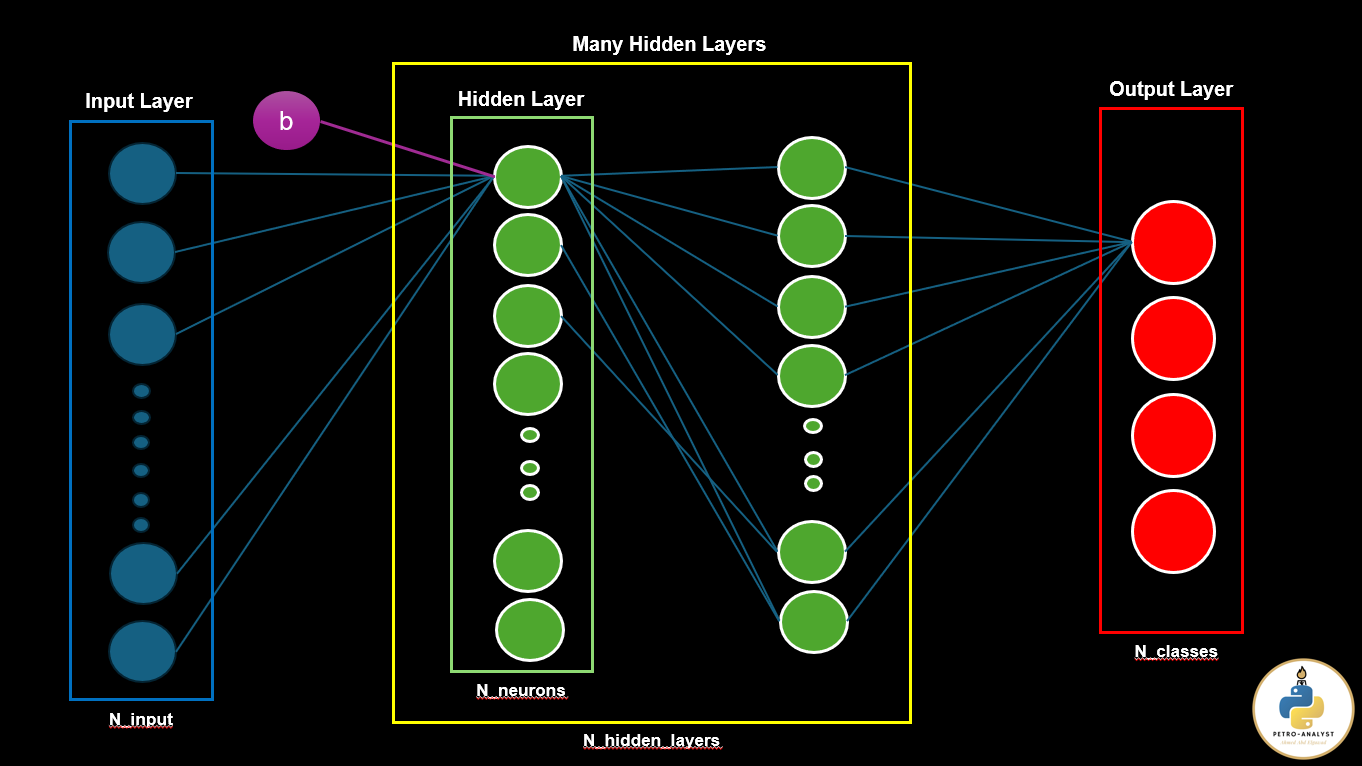chment:systemgenerated_image_name.extension)

In [3]:
class ClassificationModel(torch.nn.Module):
    def __init__(self, n_input, n_neurons, n_hidden_layers, n_classes):
        super().__init__()
        
        # Input layer
        self.input = torch.nn.Linear(n_input, n_neurons)
        
        # Hidden layers
        self.hidden_layers = torch.nn.ModuleList([
            torch.nn.Linear(n_neurons, n_neurons) for _ in range(n_hidden_layers)
        ])
        
        # Output layer
        self.out = torch.nn.Linear(n_neurons, n_classes)
        
        # Activation function
        self.relu = torch.nn.ReLU()
        
    def forward(self, X):
        x = self.relu(self.input(X))
        
        # Pass through hidden layers
        for layer in self.hidden_layers:
            x = self.lrelu(layer(x))
            
        x = self.out(x)
        return x


**Test The Model `Forward Pass`**

In [4]:
x = torch.randn(size=(50,2))
x[:5]

tensor([[ 1.9269,  1.4873],
        [ 0.9007, -2.1055],
        [ 0.6784, -1.2345],
        [-0.0431, -1.6047],
        [-0.7521,  1.6487]])

In [5]:

test_model = ClassificationModel(n_input = 2 , n_hidden_layers=2 , n_neurons = 10 , n_classes = 1)
logits = test_model(x)
logits[:5]

tensor([[0.0823],
        [0.0188],
        [0.0225],
        [0.0199],
        [0.0304]], grad_fn=<SliceBackward0>)

In [6]:
test_model.state_dict()

OrderedDict([('input.weight',
              tensor([[ 0.1106, -0.6222],
                      [-0.3047, -0.4233],
                      [ 0.0020, -0.2631],
                      [-0.0490, -0.4792],
                      [-0.4854, -0.4125],
                      [-0.2420, -0.5581],
                      [ 0.5929, -0.1403],
                      [ 0.6084,  0.2203],
                      [-0.5988,  0.4893],
                      [-0.1946, -0.2711]])),
             ('input.bias',
              tensor([-0.5869, -0.7030,  0.2023, -0.1545,  0.2753, -0.5803,  0.5250, -0.5191,
                      -0.1221,  0.1477])),
             ('hidden_layers.0.weight',
              tensor([[ 0.1633,  0.2553,  0.2881, -0.2507,  0.0796, -0.1360, -0.0347, -0.2367,
                        0.2880, -0.2321],
                      [ 0.1690,  0.1111,  0.1028, -0.1710,  0.2874,  0.0695,  0.0407, -0.2787,
                        0.1327, -0.0474],
                      [-0.1449,  0.2716,  0.0705, -0.1750, -0.1601, 

<a id="section-two"></a>
# <div style="color:#fff;display:fill;border-radius:10px;background-color:#0C2D48;text-align:center;letter-spacing:0.1px;overflow:hidden;padding:20px;color:white;overflow:hidden;margin:0;font-size:100%">Binary Classificaiton</div>

#### **For Binary Classificaiton**
1. Define the **`loss Function`** and i will use **`BCEWithLogitsLoss`** This loss function require only the logits from the model without the apply sigmoid activation.
2. As **`Optimizer`** i will use **`SGS`**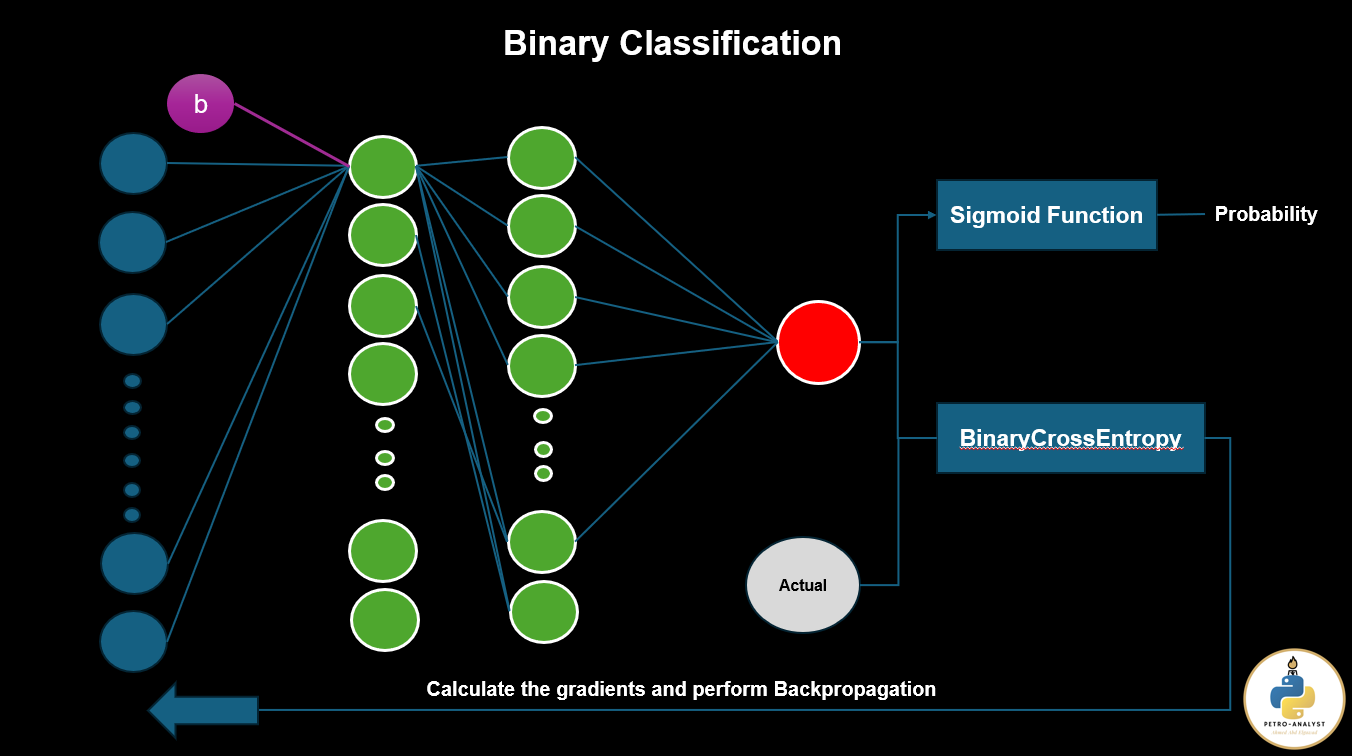

#### **Creating the `Dataset`**

In [7]:
from sklearn.datasets import make_moons

In [8]:
x , y = make_moons(n_samples = NUM_SAMPLES , noise = 0.1 , random_state = RANDOM_SEED)

In [9]:
x.shape , y.shape

((1000, 2), (1000,))

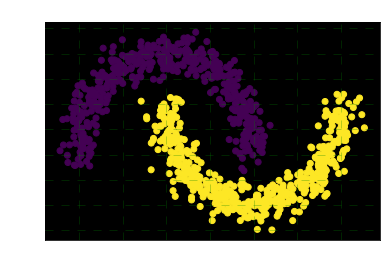

In [10]:
plt.title("2D Binary Classification Dataset")
plt.scatter(x[:,0] , x[:,1] , c=y);

In [11]:
# creating the tensors for the model input 
from torch.utils.data import TensorDataset

In [12]:
X_train , X_test , y_train , y_test = train_test_split(x,y,test_size= 0.2 , random_state = RANDOM_SEED)

In [13]:
X_train = torch.from_numpy(X_train).type(torch.float)
X_test = torch.from_numpy(X_test).type(torch.float)
y_train = torch.from_numpy(y_train).type(torch.float)
y_test = torch.from_numpy(y_test).type(torch.float)

In [21]:
# define the losss and the optimizer
model_binary = ClassificationModel(n_input = 2 , n_hidden_layers=8 , n_neurons = 20 , n_classes = 1)
loss_fn_binary = torch.nn.BCEWithLogitsLoss() # this loss function take the logits and perform a builtin sigmoid function
optimizer = torch.optim.SGD(params=model_binary.parameters(), lr=0.1)


In [22]:
#test the model validity
y_logits = model_binary(X_train).squeeze()
print(loss_fn_binary(y_logits,y_train) )

y_prob = torch.sigmoid(y_logits)

y_prob.round()[:5] # so that if the prob is >0.5 it is considered class 1


tensor(0.6932, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


tensor([1., 1., 1., 1., 1.], grad_fn=<SliceBackward0>)

In [23]:
# accuracy 
def accuracy(model_prob , true_y):
    return ((model_prob.round() == true_y).sum() )/ len(true_y)
    
accuracy(y_prob , y_train)

tensor(0.5000)

In [24]:
# built the training loop

epochs = 1000
epochs_steps = range(epochs)
training_loss_steps = []
validation_loss_steps = []
training_accuracy_steps = []
validation_accuracy_steps = []

for epoch in epochs_steps:
    ### Training
    
    # put the model on training mode
    model_binary.train()
    
    # perform the forward pass
    y_logits = model_binary(X_train).squeeze()
    
    # calculate the loss 
    train_loss = loss_fn_binary(y_logits , y_train)
    training_loss_steps.append(train_loss.item())
    
    # calculate the gradients
    train_loss.backward()
    
    # update the model parameters
    optimizer.step()
    
    # zero the gradients again to prevent accumelation
    optimizer.zero_grad()
    
    # calculate the accuracy
    y_prob = torch.sigmoid(y_logits)
    training_acc = accuracy(y_prob,y_train)
    training_accuracy_steps.append(training_acc)
    
    ### Validation
    model_binary.eval()
    with torch.no_grad():
            # perform the forward pass
        y_logits = model_binary(X_test).squeeze()

        # calculate the loss 
        val_loss = loss_fn_binary(y_logits , y_test)
        validation_loss_steps.append(val_loss.item())

        # calculate the accuracy
        y_prob = torch.sigmoid(y_logits)
        val_acc = accuracy(y_prob,y_test)
        validation_accuracy_steps.append(val_acc)
        

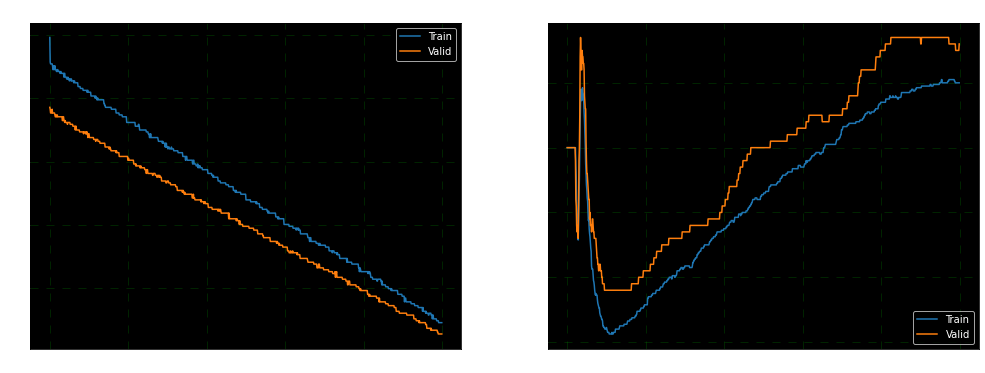

In [25]:
fig, ax = plt.subplots(1,2,figsize=(17,6))

ax[0].plot(epochs_steps ,training_loss_steps ,label="Train")
ax[0].plot(epochs_steps ,validation_loss_steps ,label="Valid" )
ax[0].set_title("Loss Profile")
ax[0].legend()

ax[1].plot(epochs_steps ,training_accuracy_steps ,label="Train" )
ax[1].plot(epochs_steps ,validation_accuracy_steps ,label="Valid" )
ax[1].set_title("Accuracy Profile");
ax[1].legend();

### **Show the model Decision Boundry**

In [26]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())



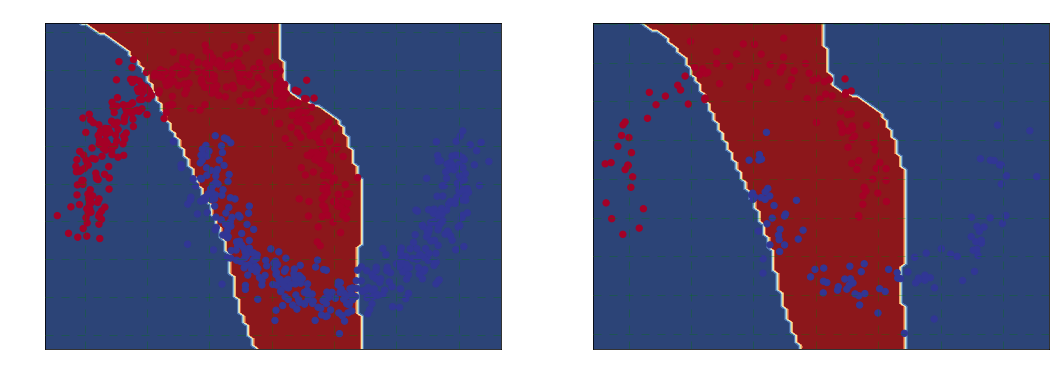

In [27]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_binary, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_binary, X_test, y_test)

<a id="section-two"></a>
# <div style="color:#fff;display:fill;border-radius:10px;background-color:#0C2D48;text-align:center;letter-spacing:0.1px;overflow:hidden;padding:20px;color:white;overflow:hidden;margin:0;font-size:100%">Multi-Class Classification</div>

#### **For Multi-Class Classificaiton**
1. Define the **`loss Function`** and i will use **`CrossEntropyLoss`** This loss function require only the logits from the model without the apply softmax activation.
2. As **`Optimizer`** i will use **`SGS`**

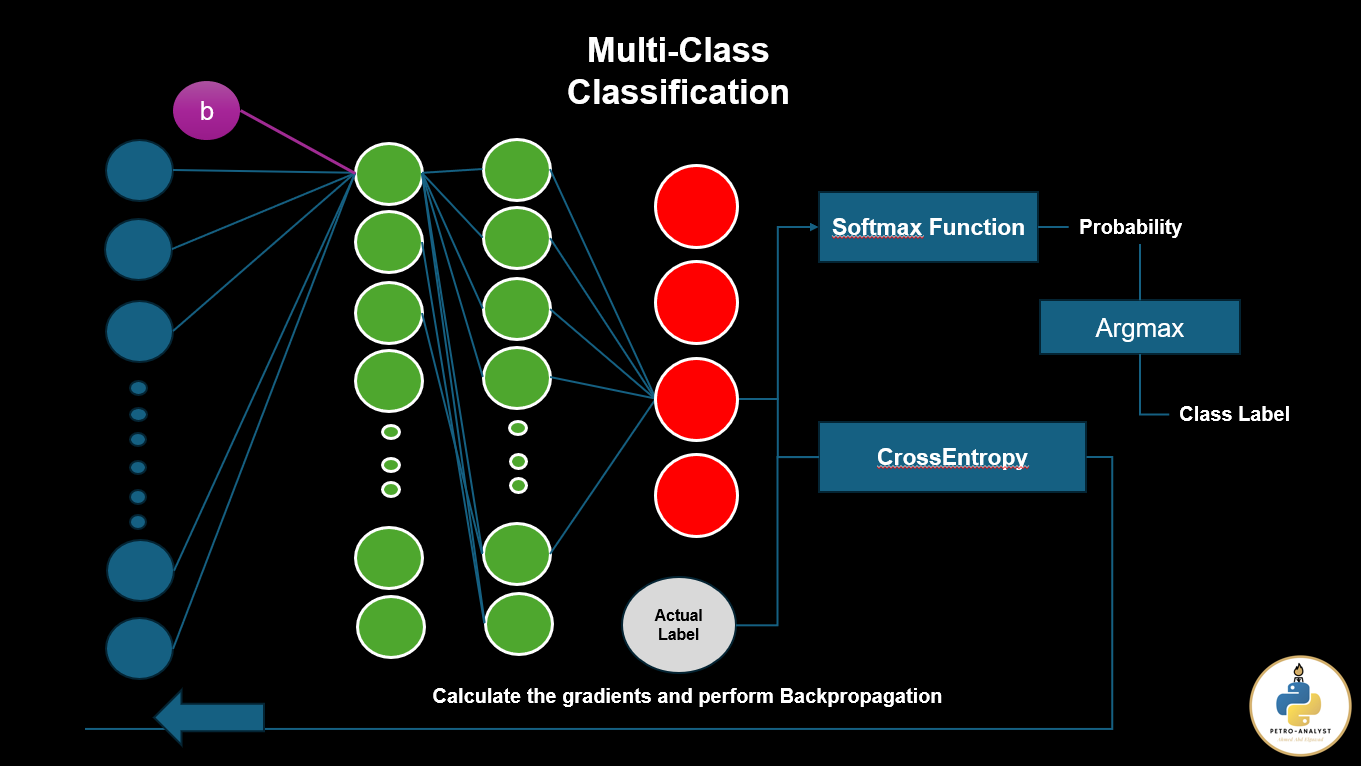

#### **Creating The **`Dataset`****

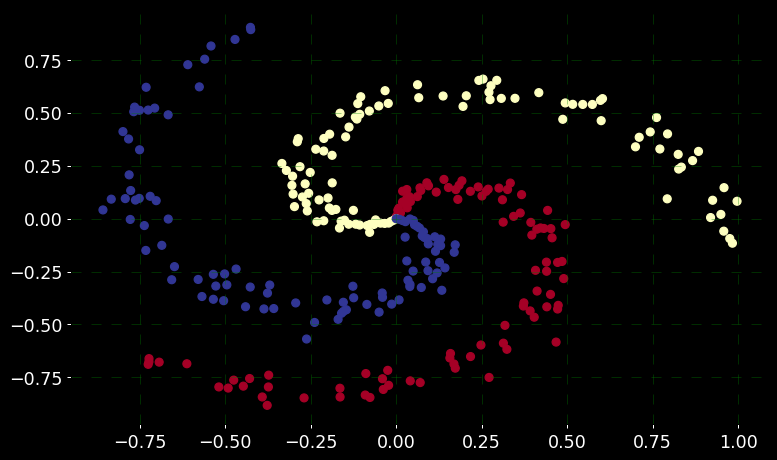

In [28]:
np.random.seed(RANDOM_SEED)
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()

In [29]:
X = torch.from_numpy(X).type(torch.float) # features as float32
y = torch.from_numpy(y).type(torch.LongTensor) # labels need to be of type long

In [30]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size= 0.2 , random_state = RANDOM_SEED)

In [36]:
# define the losss and the optimizer
model_multi = ClassificationModel(n_input = 2 , n_hidden_layers=2 , n_neurons = 15 , n_classes = 4)
loss_fn_multi = torch.nn.CrossEntropyLoss() # this loss function take the logits and perform a builtin sigmoid function
optimizer = torch.optim.SGD(params=model_multi.parameters(), lr=0.1)


**Test Model Forward Path**

In [37]:
y_logits = model_multi(X_train)

loss_fn_multi(y_logits , y_train)

probs = torch.softmax(y_logits , dim=1)
labels = torch.argmax(probs , dim=1)


In [38]:
# built the training loop

epochs = 1000
epochs_steps = range(epochs)
training_loss_steps = []
validation_loss_steps = []
training_accuracy_steps = []
validation_accuracy_steps = []

for epoch in epochs_steps:
    ### Training
    
    # put the model on training mode
    model_multi.train()
    
    # perform the forward pass
    y_logits_train = model_multi(X_train).squeeze()
    
    # calculate the loss 
    train_loss = loss_fn_multi(y_logits_train , y_train)
    training_loss_steps.append(train_loss.item())
    
    # calculate the gradients
    train_loss.backward()
    
    # update the model parameters
    optimizer.step()
    
    # zero the gradients again to prevent accumelation
    optimizer.zero_grad()
    
    # calculate the accuracy
    y_prob_train = torch.softmax(y_logits_train , dim=1)
    y_labels_train = torch.argmax(y_prob_train ,dim=1)
    train_acc = accuracy(y_labels_train , y_train)
    training_accuracy_steps.append(train_acc)
    
    ### Validation
    model_multi.eval()
    with torch.no_grad():
            # perform the forward pass
        y_logits = model_multi(X_test).squeeze()

        # calculate the loss 
        val_loss = loss_fn_multi(y_logits , y_test)
        validation_loss_steps.append(val_loss.item())

        # calculate the accuracy
        y_prob = torch.softmax(y_logits , dim=1)
        y_labels = torch.argmax(y_prob ,dim=1)
        val_acc = accuracy(y_labels,y_test)
        validation_accuracy_steps.append(val_acc)
        

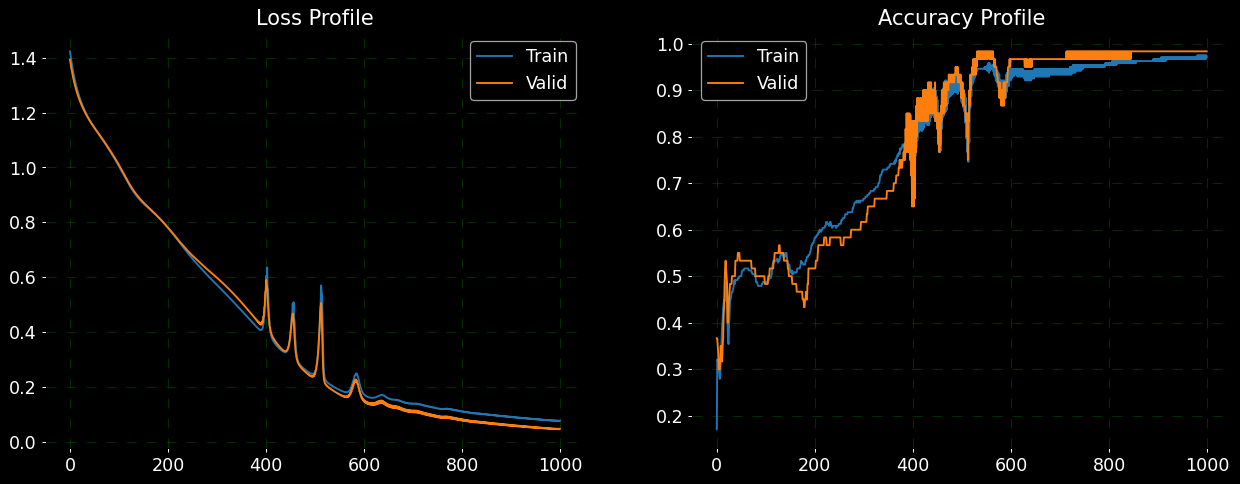

In [39]:
fig, ax = plt.subplots(1,2,figsize=(17,6))

ax[0].plot(epochs_steps ,training_loss_steps ,label="Train")
ax[0].plot(epochs_steps ,validation_loss_steps ,label="Valid" )
ax[0].set_title("Loss Profile")
ax[0].legend()

ax[1].plot(epochs_steps ,training_accuracy_steps ,label="Train" )
ax[1].plot(epochs_steps ,validation_accuracy_steps ,label="Valid" )
ax[1].set_title("Accuracy Profile");
ax[1].legend();

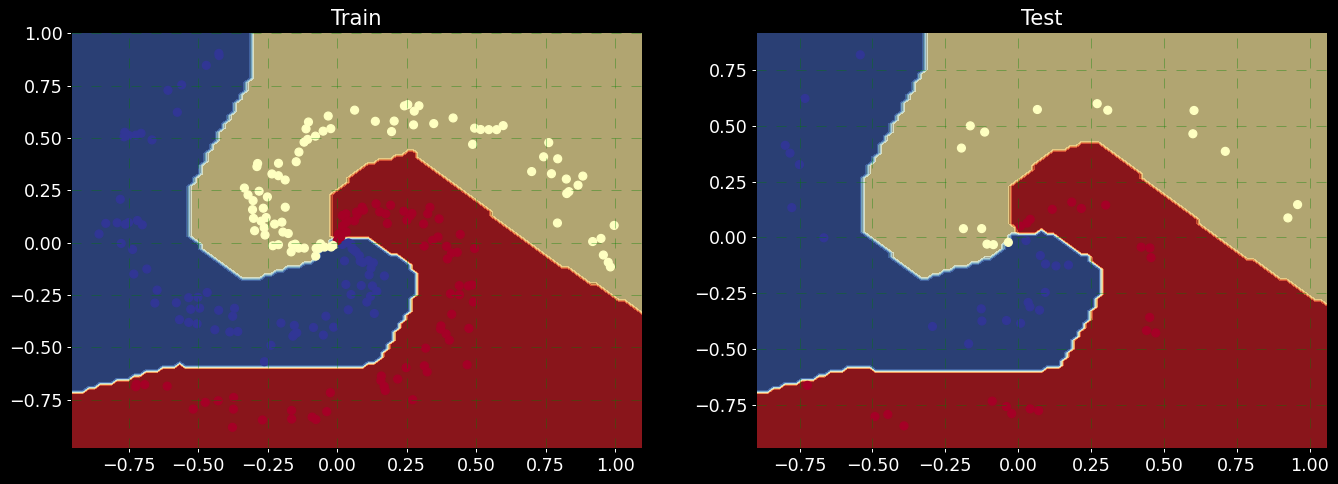

In [40]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_multi, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_multi, X_test, y_test)